<a href="https://colab.research.google.com/github/theyugster/Intro_To_ML/blob/main/U4CSE24252(K_Means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('geyser')
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long


In [10]:
feature_cols = ['duration','waiting']
x = df[feature_cols]
y = df.kind
print(y)

0       long
1      short
2       long
3      short
4       long
       ...  
267     long
268    short
269     long
270    short
271     long
Name: kind, Length: 272, dtype: object


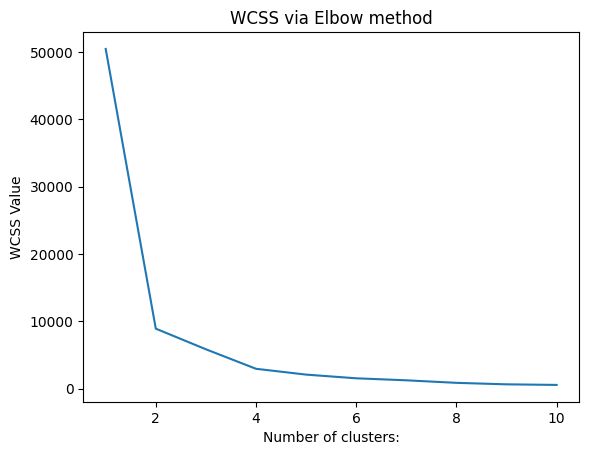

In [11]:
wcss=[]
for i in range(1,11):
  model=KMeans (n_clusters=i,init='k-means++',random_state=21)
  model.fit(x)
  wcss.append (model.inertia_)
plt.plot (range(1,11),wcss)
plt.title('WCSS via Elbow method')
plt.xlabel('Number of clusters:')
plt.ylabel('WCSS Value')
plt.show ()

In [12]:
model = KMeans(n_clusters=4,init='k-means++', random_state=42)
y_means=model.fit_predict (x)
print("y_means:\n\n",y_means)

y_means:

 [2 3 2 1 0 3 0 0 3 0 3 0 2 3 0 3 1 0 3 2 3 3 2 2 2 0 3 2 2 2 2 2 1 2 2 3 3
 2 1 0 2 1 0 1 2 0 1 3 0 1 2 0 3 2 3 0 2 1 2 2 1 0 3 0 1 0 2 2 1 2 0 1 2 2
 1 2 1 2 2 0 2 0 2 1 2 0 2 2 3 0 1 0 3 2 1 2 0 2 3 0 1 0 3 0 2 3 0 3 0 2 2
 1 0 2 1 2 3 0 1 0 3 2 2 1 0 2 3 0 3 0 3 0 1 0 3 0 3 0 3 2 2 1 0 2 2 1 2 3
 0 3 2 2 1 2 2 2 2 0 3 0 3 0 1 2 1 2 1 0 3 0 3 1 2 1 2 2 2 3 0 2 3 2 0 0 3
 2 0 3 0 3 2 1 2 0 2 2 0 2 3 2 1 0 0 3 2 3 2 0 3 0 2 2 3 2 1 2 3 0 3 2 3 0
 3 2 2 2 2 2 2 2 2 3 0 3 0 3 3 2 2 1 2 3 0 1 0 0 1 0 1 2 3 0 2 2 0 2 2 0 1
 2 2 0 1 0 3 1 2 2 3 0 3 2]


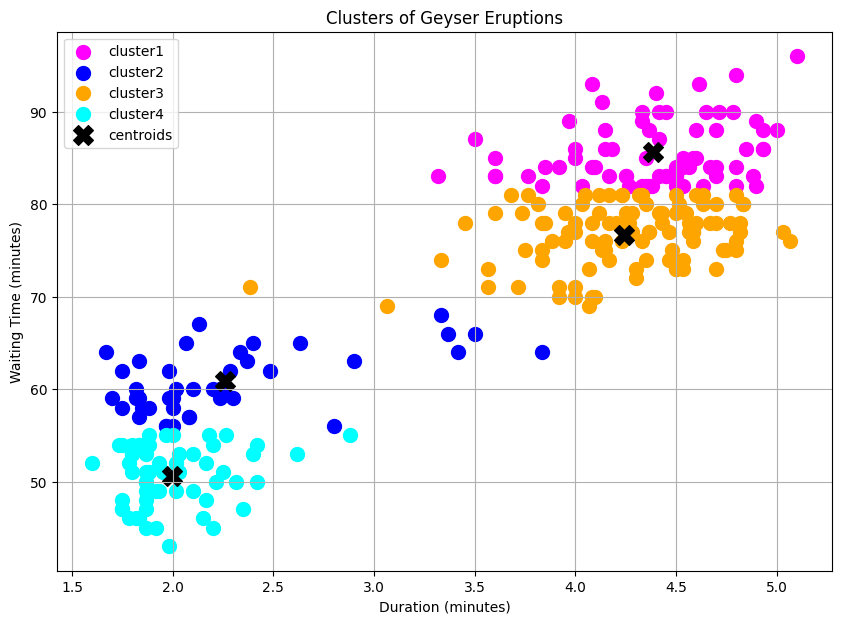

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(x.values[y_means==0,0], x.values[y_means==0,1],s=100,c='magenta', label='cluster1')
plt.scatter(x.values[y_means==1,0],x.values[y_means==1,1],s=100,c='blue', label='cluster2')
plt.scatter(x.values[y_means==2,0],x.values[y_means==2,1],s=100,c='orange',label='cluster3')
plt.scatter(x.values[y_means==3,0], x.values[y_means==3,1],s=100,c='cyan',label='cluster4')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],s=200,c='black',label='centroids', marker='X')
plt.title('Clusters of Geyser Eruptions')
plt.xlabel('Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.legend()
plt.grid(True)
plt.show()

Success! The image shape is: (396, 396, 3)


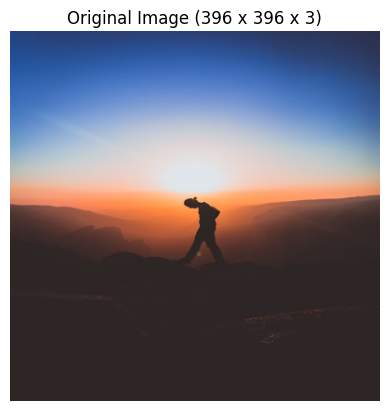

In [16]:
import urllib.request
from PIL import Image
url = "https://images.unsplash.com/photo-1506748686214-e9df14d4d9d0?auto=format&fit=crop&w=600&q=80"
urllib.request.urlretrieve(url, "sample_image.jpg")


img = Image.open("sample_image.jpg").convert('RGB')
img_resized = img.resize((396, 396))


img_array = np.array(img_resized)


print(f"Success! The image shape is: {img_array.shape}")


plt.imshow(img_array)
plt.title("Original Image (396 x 396 x 3)")
plt.axis('off')
plt.show()

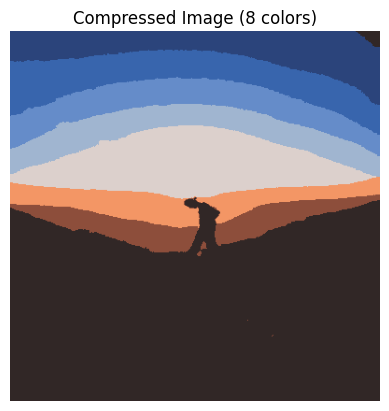

In [17]:
img_reshaped = img_array.reshape(-1, 3)

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans.fit(img_reshaped)

compressed_colors = kmeans.cluster_centers_[kmeans.labels_]
compressed_image_array = compressed_colors.reshape(img_array.shape).astype(int)

plt.imshow(compressed_image_array)
plt.title("Compressed Image (8 colors)")
plt.axis('off')
plt.show()